In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import csv

from datasets import Dataset, features

from llm_mri import ActivationAreas
from llm_mri.dimensionality_reduction import UMAP

import sys
sys.path.insert(0, '../') 
from utils.neural_region_extraction import extract_neural_region_data

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utils

In [17]:
# constants
RAW_DATASET_PATH = "data/raw/"
INTERIM_DATASET_PATH = "data/interim/"
PROCESSED_DATASET_PATH = "data/processed/"
GRAPH_PATH = f"{INTERIM_DATASET_PATH}graphs/"
COMPLETE_GRAPH_PATH = f"{GRAPH_PATH}complete/"
FILTERED_GRAPH_PATH = f"{GRAPH_PATH}filtered/"
DATASETS_NAMES = ["subj_number", "tree_depth", "word_content", "bigram_shift", "odd_man_out", "sentence_length"]

DATASETS_MAP = {
  "surface": ["sentence_length", "word_content"],
  "syntactic": ["bigram_shift", "tree_depth"],
  "semantic": ["odd_man_out", "subj_number"]
}

model_ckpt = "bert-base-uncased"

## Get Graphs and Activations

In [16]:
labels = dict()
for dataset_name in DATASETS_NAMES:

    print(f"Processing dataset: {dataset_name}")
    # 1. Carregar o arquivo .txt (ajuste o caminho conforme necessário)
    # O separador costuma ser tabulação ou espaço, dependendo da versão
    df = pd.read_csv(
        f"{RAW_DATASET_PATH}{dataset_name}.txt",
        sep="\t",
        names=["split", "label", "text"],
        quoting=csv.QUOTE_NONE
    )

    print(f"Dataset '{dataset_name}' carregado com {len(df)} amostras.")

    # 2. Filtrar apenas o que você deseja (ex: apenas o split de treino 'tr')
    df = df.drop(columns=["split"])

    # 3. Criar o Dataset do Hugging Face (como feito no notebook Emotions.ipynb)
    dataset = Dataset.from_pandas(df.reset_index(drop=True))

    # 4. Mapear as labels para ClassLabel (essencial para o LLM-MRI)
    class_names = [str(x) for x in sorted(dataset.unique("label"))]
    labels[dataset_name] = class_names
    class_feature = features.ClassLabel(names=class_names)
    dataset = dataset.map(lambda x: {"label": class_feature.str2int(str(x["label"]))})
    dataset = dataset.cast(
        features.Features({"label": class_feature, "text": dataset.features["text"]})
    )

    # 5. Processar as áreas de ativação usando o LLM-MRI

    umap = UMAP(n_components=2, random_state=42, gridsize=15)
    llm_mri = ActivationAreas(
        model=model_ckpt, device="cpu", dataset=dataset, reduction_method=umap
    )
    llm_mri.process_activation_areas(
        # save_raw_path="data/dados_hf_brutos",
        # save_reduced_path="data/reduzidos.pt",
        # save_jsonl_path=f"{INTERIM_DATASET_PATH}/{dataset_name}_features.json"
    )
    
    # ✅ EXTRAIR - Escolha formato
    extractor = extract_neural_region_data(
        llm_mri, 
        output_dir=f"{INTERIM_DATASET_PATH}/neural_regions_{dataset_name}",
        format='hdf5'  # ou 'npz'
    )

    for label in class_names:
        current_graph = llm_mri.get_graph(label)
        nx.write_gexf(
            current_graph, f"{COMPLETE_GRAPH_PATH}/g_{label}_{dataset_name}.gexf"
        )

    total_graph = llm_mri.get_graph(class_names)
    nx.write_gexf(total_graph, f"{COMPLETE_GRAPH_PATH}/g_total_{dataset_name}.gexf")

Processing dataset: subj_number
Dataset 'subj_number' carregado com 10000 amostras.


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

[INFO] Checking for tokenization overflow...


Map: 100%|██████████| 10000/10000 [02:07<00:00, 78.19 examples/s]
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 

...

Extraindo e salvando dados de regiões neurais...
------------------------------------------------------------
✓ Region assignments salvos em: data/interim/neural_regions_odd_man_out/region_assignments.csv
  Shape: (130000, 6)
✓ Region activations (HDF5) salvos em: data/interim/neural_regions_odd_man_out/region_activations.h5
  Total de regiões: 952
✓ Samples per region salvos em: data/interim/neural_regions_odd_man_out/samples_per_region.json
------------------------------------------------------------
✓ Todos os dados salvos em: data/interim/neural_regions_odd_man_out
  Arquivos gerados:
    - region_assignments.csv (mapeamento amostra → região)
    - region_activations.hdf5 (ativações 768D por região)
    - samples_per_region.json (índice reverso)
    - raw_activations_by_region.jsonl (inspeção visual)
    - region_statistics.csv (estatísticas)
Processing dataset: sentence_length
Dataset 'sentence_length' carregado com 9996 amostras.


Map:   0%|          | 0/9996 [00:00<?, ? examples/s]

[INFO] Checking for tokenization overflow...


Map: 100%|██████████| 9996/9996 [02:56<00:00, 56.63 examples/s]
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by

Extraindo e salvando dados de regiões neurais...
------------------------------------------------------------
✓ Region assignments salvos em: data/interim/neural_regions_sentence_length/region_assignments.csv
  Shape: (129948, 6)
✓ Region activations (HDF5) salvos em: data/interim/neural_regions_sentence_length/region_activations.h5
  Total de regiões: 979
✓ Samples per region salvos em: data/interim/neural_regions_sentence_length/samples_per_region.json
------------------------------------------------------------
✓ Todos os dados salvos em: data/interim/neural_regions_sentence_length
  Arquivos gerados:
    - region_assignments.csv (mapeamento amostra → região)
    - region_activations.hdf5 (ativações 768D por região)
    - samples_per_region.json (índice reverso)
    - raw_activations_by_region.jsonl (inspeção visual)
    - region_statistics.csv (estatísticas)


# Probing


Dataset: subj_number
Total de (amostra, camada, região): 130000
Unique regions: 928
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 928
Regiões com pelo menos 8 amostras: 865
  ✓ Processadas 50 regiões...
  ✓ Processadas 100 regiões...
  ✓ Processadas 150 regiões...
  ✓ Processadas 200 regiões...
  ✓ Processadas 250 regiões...
  ✓ Processadas 300 regiões...
  ✓ Processadas 350 regiões...
  ✓ Processadas 400 regiões...
  ✓ Processadas 450 regiões...
  ✓ Processadas 500 regiões...
  ✓ Processadas 550 regiões...
  ✓ Processadas 600 regiões...
  ✓ Processadas 650 regiões...
  ✓ Processadas 700 regiões...
  ✓ Processadas 750 regiões...
  ✓ Processadas 800 regiões...

RELATÓRIO DE EXECUÇÃO - subj_number
Total de regiões analisadas: 928
Regiões com probing bem-sucedido: 855

Regiões puladas:
  - Muito poucas amostras: 63
  - Apenas 1 classe: 10
  - Erro no split: 10
  - Erro no fit: 0

✓ Estatísticas de Acurácia:
count    855.000000
mean       0.685858
std        0.167786
min  

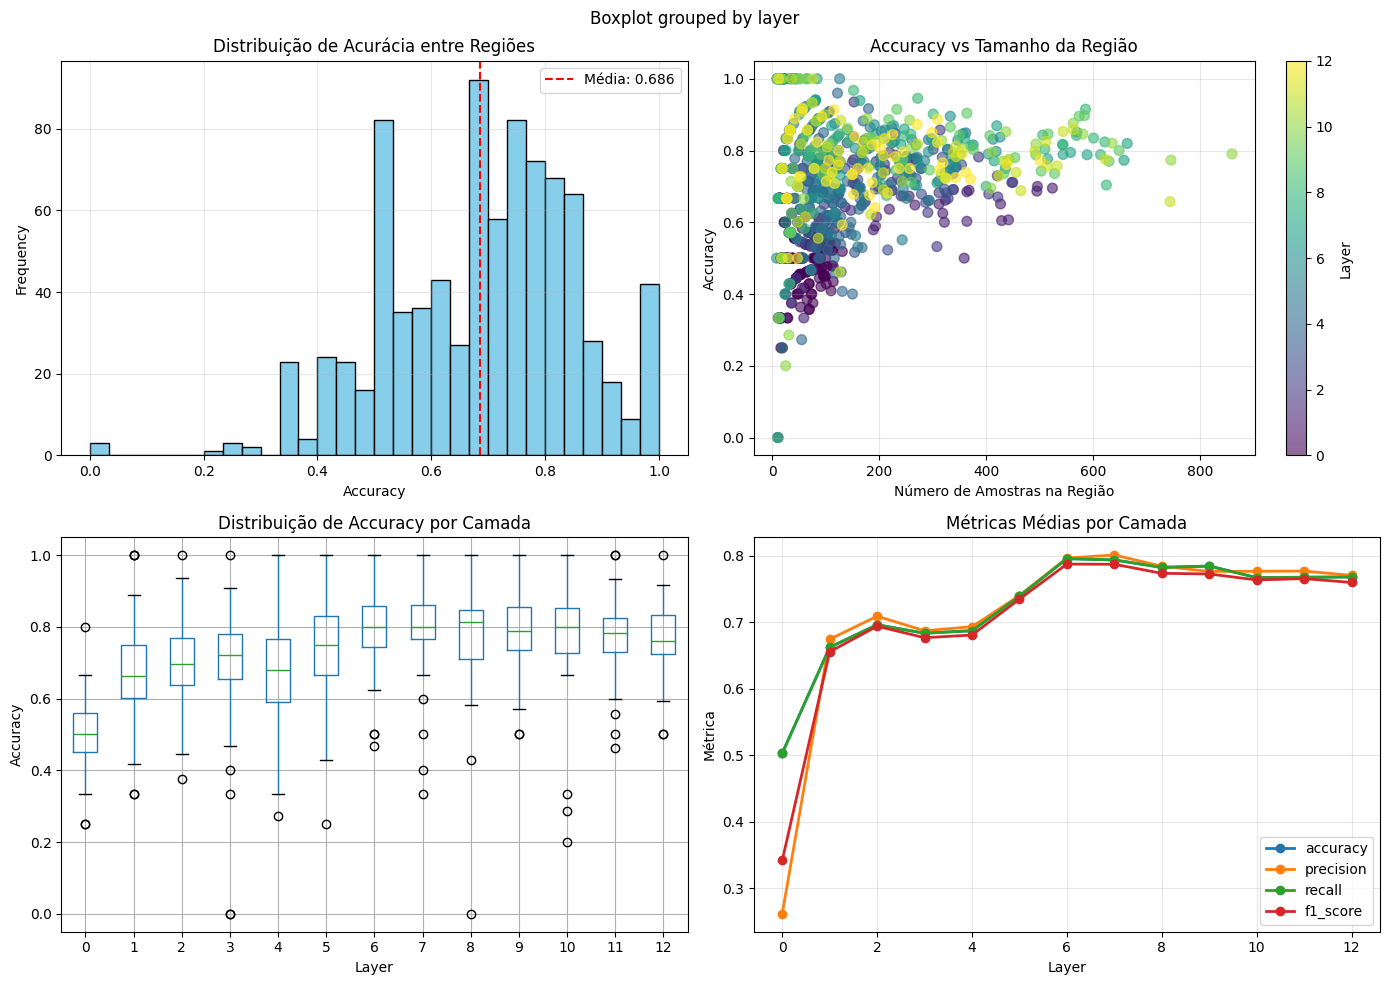


AMOSTRA DOS RESULTADOS


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
737,10,10_2_9,860,2,NN:409; NNS:451,NN:327; NNS:361,NN:82; NNS:90,688,172,0.790698,0.792340,0.790698,0.789784
746,10,10_4_11,746,2,NN:412; NNS:334,NN:329; NNS:267,NN:83; NNS:67,596,150,0.773333,0.773890,0.773333,0.771348
774,11,11_1_5,744,2,NN:326; NNS:418,NN:261; NNS:334,NN:65; NNS:84,595,149,0.657718,0.658341,0.657718,0.658000
602,7,7_1_6,664,2,NN:308; NNS:356,NN:246; NNS:285,NN:62; NNS:71,531,133,0.819549,0.825659,0.819549,0.819630
609,7,7_2_3,658,2,NN:385; NNS:273,NN:308; NNS:218,NN:77; NNS:55,526,132,0.772727,0.771363,0.772727,0.771316
689,9,9_11_8,649,2,NN:315; NNS:334,NN:252; NNS:267,NN:63; NNS:67,519,130,0.800000,0.803136,0.800000,0.799858
745,10,10_4_10,636,2,NN:267; NNS:369,NN:213; NNS:295,NN:54; NNS:74,508,128,0.820312,0.819674,0.820312,0.819531
702,9,9_13_11,630,2,NN:356; NNS:274,NN:285; NNS:219,NN:71; NNS:55,504,126,0.769841,0.771858,0.769841,0.770413
641,8,8_11_4,625,2,NN:323; NNS:302,NN:258; NNS:242,NN:65; NNS:60,500,125,0.704000,0.706614,0.704000,0.701583
788,11,11_3_3,623,2,NN:314; NNS:309,NN:251; NNS:247,NN:63; NNS:62,498,125,0.776000,0.776226,0.776000,0.775914


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
535,6,6_12_6,8,2,NN:5; NNS:3,NN:4; NNS:2,NN:1; NNS:1,6,2,0.500000,0.250000,0.500000,0.333333
713,9,9_1_8,9,2,NN:2; NNS:7,NN:2; NNS:5,NNS:2,7,2,1.000000,1.000000,1.000000,1.000000
709,9,9_14_8,9,1,NNS:9,None,None,0,0,1.000000,1.000000,1.000000,1.000000
457,4,4_9_3,9,1,NNS:9,None,None,0,0,1.000000,1.000000,1.000000,1.000000
205,1,1_1_5,9,2,NN:6; NNS:3,NN:5; NNS:2,NN:1; NNS:1,7,2,1.000000,1.000000,1.000000,1.000000
335,3,3_8_7,10,2,NN:5; NNS:5,NN:4; NNS:4,NN:1; NNS:1,8,2,0.000000,0.000000,0.000000,0.000000
631,8,8_10_1,10,2,NN:5; NNS:5,NN:4; NNS:4,NN:1; NNS:1,8,2,0.000000,0.000000,0.000000,0.000000
663,8,8_14_9,11,2,NN:3; NNS:8,NN:2; NNS:6,NN:1; NNS:2,8,3,0.666667,0.833333,0.666667,0.666667
624,7,7_4_7,11,2,NN:3; NNS:8,NN:2; NNS:6,NN:1; NNS:2,8,3,0.666667,0.833333,0.666667,0.666667
591,7,7_13_6,11,2,NN:7; NNS:4,NN:5; NNS:3,NN:2; NNS:1,8,3,1.000000,1.000000,1.000000,1.000000



REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
623,7,7_4_6,45,1,NNS:45,None,None,0,0,1.0,1.0,1.0,1.0
463,5,5_0_6,33,1,NNS:33,None,None,0,0,1.0,1.0,1.0,1.0
541,6,6_1_3,22,1,NNS:22,None,None,0,0,1.0,1.0,1.0,1.0
552,6,6_3_0,21,1,NNS:21,None,None,0,0,1.0,1.0,1.0,1.0
472,5,5_1_14,16,1,NNS:16,None,None,0,0,1.0,1.0,1.0,1.0
380,4,4_3_14,15,1,NNS:15,None,None,0,0,1.0,1.0,1.0,1.0
221,1,1_5_0,13,1,NN:13,None,None,0,0,1.0,1.0,1.0,1.0
578,6,6_6_7,13,1,NNS:13,None,None,0,0,1.0,1.0,1.0,1.0
457,4,4_9_3,9,1,NNS:9,None,None,0,0,1.0,1.0,1.0,1.0
709,9,9_14_8,9,1,NNS:9,None,None,0,0,1.0,1.0,1.0,1.0



Dataset: tree_depth
Total de (amostra, camada, região): 129948
Unique regions: 886
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 886
Regiões com pelo menos 8 amostras: 826
  ✓ Processadas 50 regiões...
  ✓ Processadas 100 regiões...
  ✓ Processadas 150 regiões...
  ✓ Processadas 200 regiões...
  ✓ Processadas 250 regiões...
  ✓ Processadas 300 regiões...
  ✓ Processadas 350 regiões...
  ✓ Processadas 400 regiões...
  ✓ Processadas 450 regiões...
  ✓ Processadas 500 regiões...
  ✓ Processadas 550 regiões...
  ✓ Processadas 600 regiões...
  ✓ Processadas 650 regiões...

RELATÓRIO DE EXECUÇÃO - tree_depth
Total de regiões analisadas: 886
Regiões com probing bem-sucedido: 659

Regiões puladas:
  - Muito poucas amostras: 60
  - Apenas 1 classe: 0
  - Erro no split: 167
  - Erro no fit: 0

✓ Estatísticas de Acurácia:
count    659.000000
mean       0.250427
std        0.113210
min        0.000000
25%        0.166667
50%        0.244681
75%        0.321553
max        0.800000


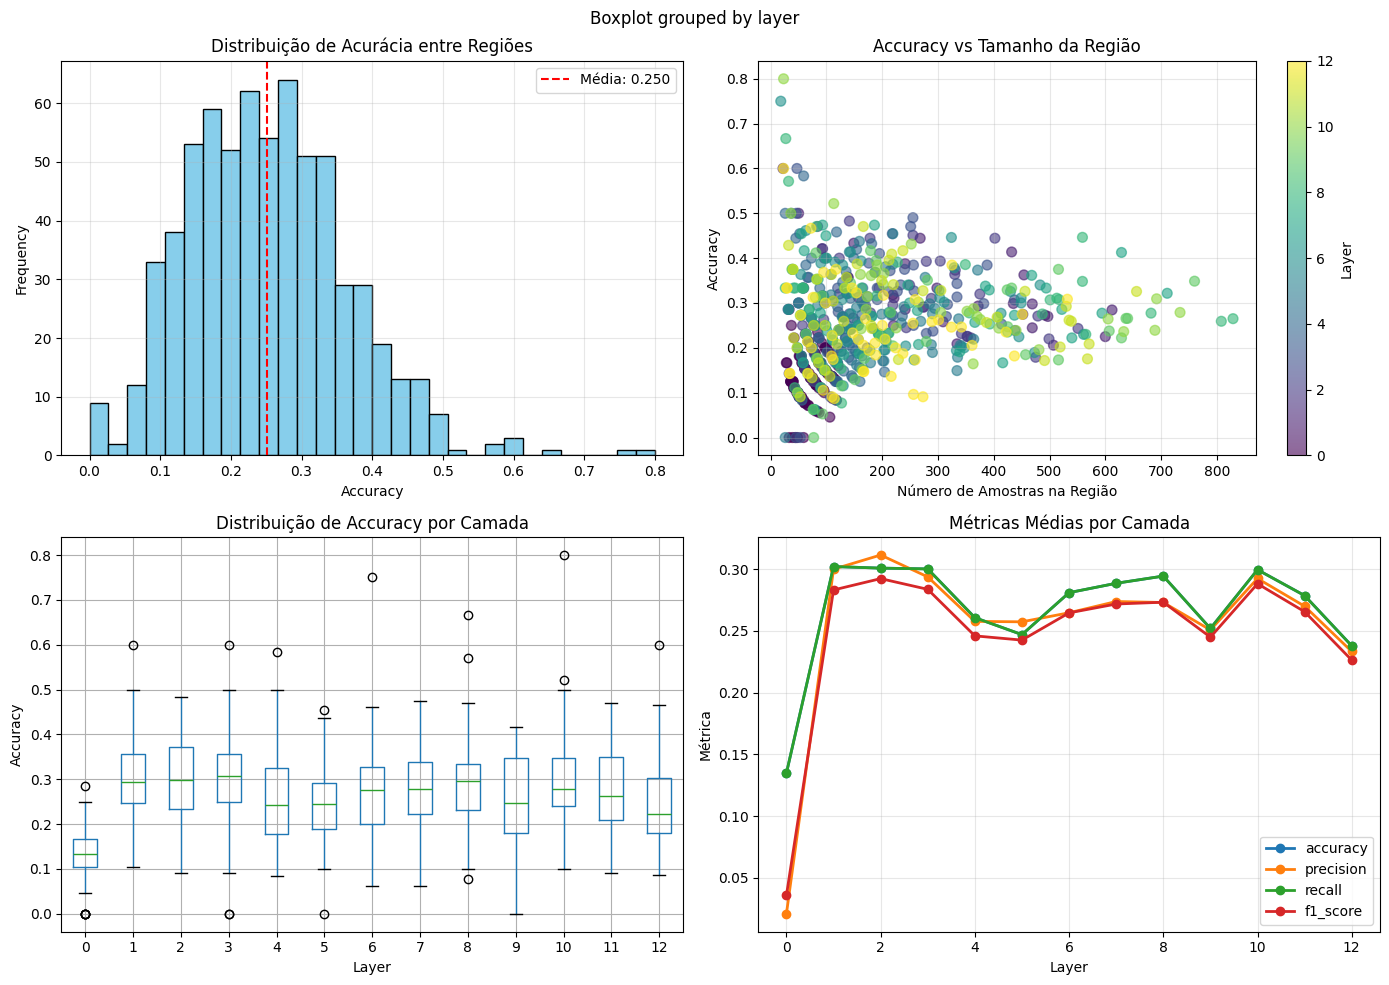


AMOSTRA DOS RESULTADOS


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
472,8,8_13_4,829,7,10:131; 11:86; 5:31; 6:119; 7:196; 8:138; 9:128,10:105; 11:69; 5:25; 6:95; 7:157; 8:110; 9:102,10:26; 11:17; 5:6; 6:24; 7:39; 8:28; 9:26,663,166,0.265060,0.266661,0.265060,0.263728
474,8,8_13_6,808,7,10:129; 11:136; 5:83; 6:100; 7:93; 8:136; 9:131,10:103; 11:109; 5:66; 6:80; 7:74; 8:109; 9:105,10:26; 11:27; 5:17; 6:20; 7:19; 8:27; 9:26,646,162,0.259259,0.260581,0.259259,0.251785
511,9,9_1_11,760,7,10:116; 11:72; 5:32; 6:116; 7:187; 8:128; 9:109,10:93; 11:58; 5:26; 6:93; 7:149; 8:102; 9:87,10:23; 11:14; 5:6; 6:23; 7:38; 8:26; 9:22,608,152,0.348684,0.322768,0.348684,0.333288
531,10,10_0_11,734,7,10:106; 11:71; 5:36; 6:99; 7:173; 8:128; 9:121,10:85; 11:57; 5:29; 6:79; 7:138; 8:102; 9:97,10:21; 11:14; 5:7; 6:20; 7:35; 8:26; 9:24,587,147,0.278912,0.291180,0.278912,0.280200
429,7,7_12_4,711,7,10:119; 11:122; 5:22; 6:67; 7:117; 8:132; 9:132,10:95; 11:97; 5:18; 6:54; 7:94; 8:105; 9:105,10:24; 11:25; 5:4; 6:13; 7:23; 8:27; 9:27,568,143,0.321678,0.354043,0.321678,0.323309
555,10,10_2_9,692,7,10:143; 11:167; 5:52; 6:55; 7:79; 8:92; 9:104,10:114; 11:133; 5:42; 6:44; 7:63; 8:74; 9:83,10:29; 11:34; 5:10; 6:11; 7:16; 8:18; 9:21,553,139,0.309353,0.302692,0.309353,0.299596
544,10,10_1_11,689,7,10:114; 11:96; 5:36; 6:97; 7:138; 8:111; 9:97,10:91; 11:77; 5:29; 6:77; 7:110; 8:89; 9:78,10:23; 11:19; 5:7; 6:20; 7:28; 8:22; 9:19,551,138,0.239130,0.232627,0.239130,0.234602
473,8,8_13_5,682,7,10:120; 11:137; 5:30; 6:67; 7:82; 8:112; 9:134,10:96; 11:109; 5:24; 6:54; 7:66; 8:89; 9:107,10:24; 11:28; 5:6; 6:13; 7:16; 8:23; 9:27,545,137,0.277372,0.258440,0.277372,0.264227
576,11,11_11_3,656,7,10:95; 11:64; 5:30; 6:104; 7:149; 8:109; 9:105,10:76; 11:51; 5:24; 6:83; 7:119; 8:87; 9:84,10:19; 11:13; 5:6; 6:21; 7:30; 8:22; 9:21,524,132,0.325758,0.321105,0.325758,0.321727
520,9,9_2_9,640,7,10:140; 11:156; 5:30; 6:48; 7:73; 8:89; 9:104,10:112; 11:125; 5:24; 6:38; 7:59; 8:71; 9:83,10:28; 11:31; 5:6; 6:10; 7:14; 8:18; 9:21,512,128,0.265625,0.269937,0.265625,0.265694


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
395,6,6_13_2,18,2,5:14; 6:4,5:11; 6:3,5:3; 6:1,14,4,0.750000,0.562500,0.750000,0.642857
151,1,1_4_10,22,3,10:6; 11:13; 9:3,10:5; 11:10; 9:2,10:1; 11:3; 9:1,17,5,0.600000,0.500000,0.600000,0.533333
561,10,10_3_9,23,4,10:9; 11:4; 8:4; 9:6,10:7; 11:3; 8:3; 9:5,10:2; 11:1; 8:1; 9:1,18,5,0.800000,0.700000,0.800000,0.733333
658,12,12_9_4,23,5,10:2; 5:8; 6:9; 7:2; 9:2,10:2; 5:6; 6:7; 7:2; 9:1,5:2; 6:2; 9:1,18,5,0.600000,0.600000,0.600000,0.600000
487,8,8_3_2,26,6,11:2; 5:4; 6:2; 7:5; 8:10; 9:3,11:1; 5:3; 6:2; 7:4; 8:8; 9:2,11:1; 5:1; 7:1; 8:2; 9:1,20,6,0.333333,0.166667,0.333333,0.222222
322,5,5_10_3,26,6,10:5; 11:3; 6:4; 7:7; 8:5; 9:2,10:4; 11:2; 6:3; 7:5; 8:4; 9:2,10:1; 11:1; 6:1; 7:2; 8:1,20,6,0.000000,0.000000,0.000000,0.000000
269,4,4_12_0,26,6,10:3; 11:2; 6:3; 7:5; 8:8; 9:5,10:2; 11:2; 6:2; 7:4; 8:6; 9:4,10:1; 6:1; 7:1; 8:2; 9:1,20,6,0.500000,0.472222,0.500000,0.416667
466,8,8_12_3,27,4,10:6; 11:8; 8:7; 9:6,10:5; 11:6; 8:5; 9:5,10:1; 11:2; 8:2; 9:1,21,6,0.666667,0.472222,0.666667,0.544444
27,0,0_1_4,28,6,10:4; 11:7; 5:5; 6:5; 7:2; 8:5,10:3; 11:5; 5:4; 6:4; 7:2; 8:4,10:1; 11:2; 5:1; 6:1; 8:1,22,6,0.166667,0.027778,0.166667,0.047619
20,0,0_12_11,29,6,10:5; 11:2; 5:4; 6:8; 8:5; 9:5,10:4; 11:2; 5:3; 6:6; 8:4; 9:4,10:1; 5:1; 6:2; 8:1; 9:1,23,6,0.166667,0.027778,0.166667,0.047619



REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score



Dataset: word_content
Total de (amostra, camada, região): 130000
Unique regions: 967
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 967
Regiões com pelo menos 8 amostras: 895

RELATÓRIO DE EXECUÇÃO - word_content
Total de regiões analisadas: 967
Regiões com probing bem-sucedido: 0

Regiões puladas:
  - Muito poucas amostras: 72
  - Apenas 1 classe: 0
  - Erro no split: 895
  - Erro no fit: 0

❌ Nenhuma região foi processada com sucesso!

Dataset: bigram_shift
Total de (amostra, camada, região): 130000
Unique regions: 979
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 979
Regiões com pelo menos 8 amostras: 926
  ✓ Processadas 50 regiões...
  ✓ Processadas 100 regiões...
  ✓ Processadas 150 regiões...
  ✓ Processadas 200 regiões...
  ✓ Processadas 250 regiões...
  ✓ Processadas 300 regiões...
  ✓ Processadas 350 regiões...
  ✓ Processadas 400 regiões...
  ✓ Processadas 450 regiões...
  ✓ Processadas 500 regiões...
  ✓ Processadas 550 regiões...
  ✓ Processa

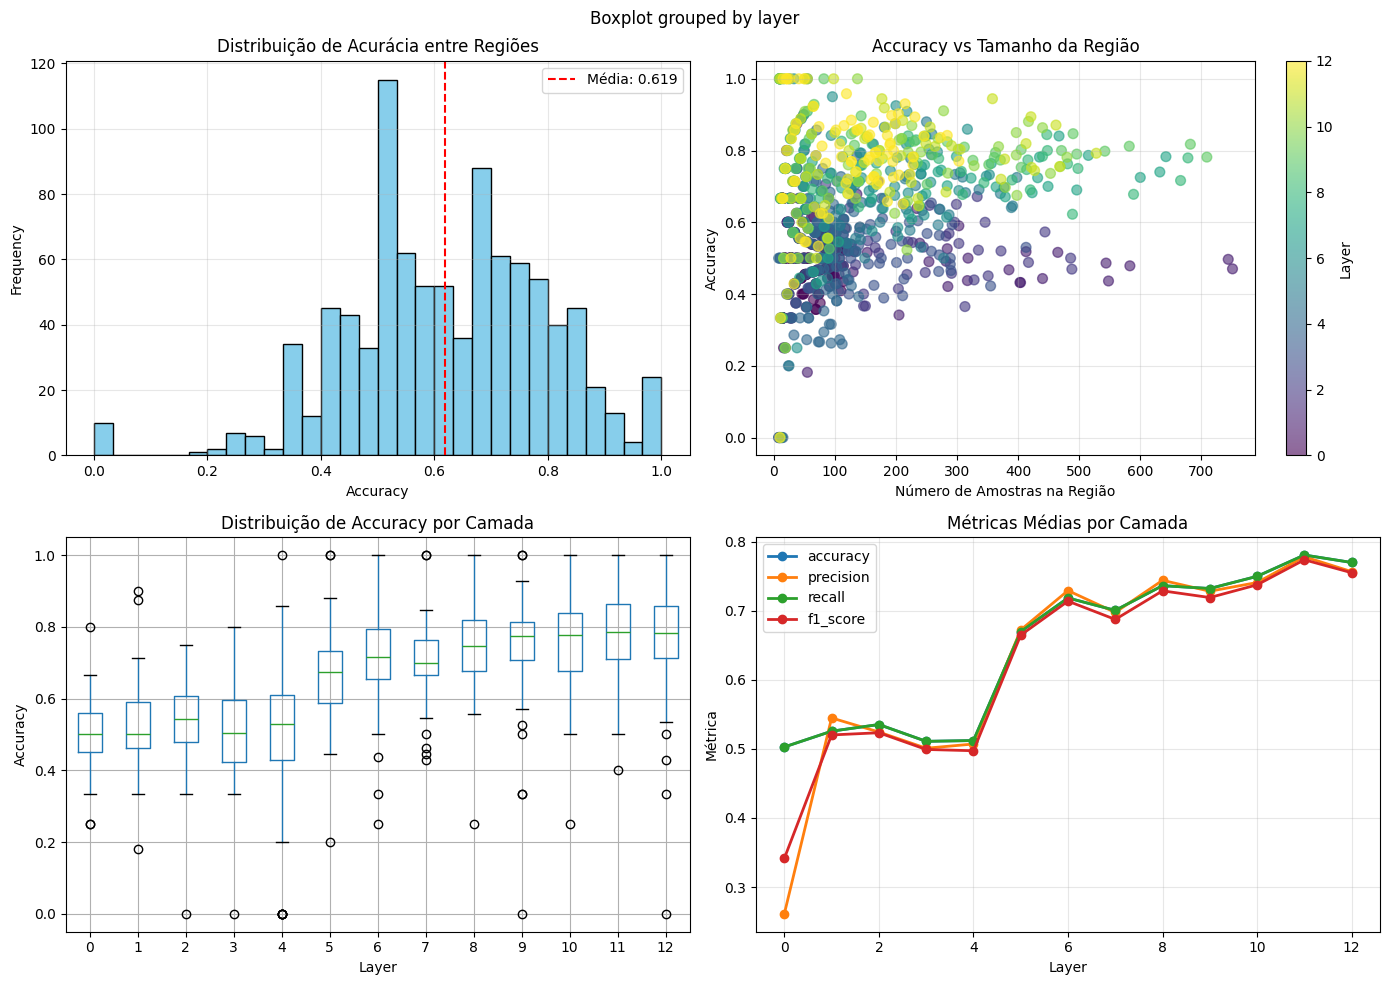


AMOSTRA DOS RESULTADOS


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
214,1,1_1_8,751,2,I:353; O:398,I:282; O:318,I:71; O:80,600,151,0.470199,0.473878,0.470199,0.469966
202,1,1_13_10,744,2,I:387; O:357,I:309; O:286,I:78; O:71,595,149,0.496644,0.496325,0.496644,0.496462
700,9,9_1_5,709,2,I:321; O:388,I:257; O:310,I:64; O:78,567,142,0.781690,0.781440,0.781690,0.781526
708,9,9_2_2,682,2,I:327; O:355,I:261; O:284,I:66; O:71,545,137,0.817518,0.817838,0.817518,0.817284
651,8,8_10_13,678,2,I:323; O:355,I:258; O:284,I:65; O:71,542,136,0.779412,0.779412,0.779412,0.779412
666,8,8_13_11,666,2,I:333; O:333,I:266; O:266,I:67; O:67,532,134,0.716418,0.718168,0.716418,0.715848
624,7,7_4_5,642,2,I:324; O:318,I:259; O:254,I:65; O:64,513,129,0.782946,0.787570,0.782946,0.782213
625,7,7_4_6,632,2,I:309; O:323,I:247; O:258,I:62; O:65,505,127,0.740157,0.744223,0.740157,0.738402
628,7,7_5_2,600,2,I:307; O:293,I:246; O:234,I:61; O:59,480,120,0.725000,0.726953,0.725000,0.724713
656,8,8_11_13,589,2,I:331; O:258,I:265; O:206,I:66; O:52,471,118,0.677966,0.677966,0.677966,0.677966


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
469,4,4_9_2,8,2,I:4; O:4,I:3; O:3,I:1; O:1,6,2,0.000000,0.000000,0.000000,0.000000
358,4,4_12_6,8,2,I:2; O:6,I:1; O:5,I:1; O:1,6,2,0.500000,0.250000,0.500000,0.333333
265,2,2_8_10,8,2,I:4; O:4,I:3; O:3,I:1; O:1,6,2,0.000000,0.000000,0.000000,0.000000
355,4,4_12_1,9,2,I:4; O:5,I:3; O:4,I:1; O:1,7,2,0.000000,0.000000,0.000000,0.000000
738,10,10_0_7,9,2,I:5; O:4,I:4; O:3,I:1; O:1,7,2,1.000000,1.000000,1.000000,1.000000
477,5,5_0_0,10,2,I:5; O:5,I:4; O:4,I:1; O:1,8,2,1.000000,1.000000,1.000000,1.000000
356,4,4_12_2,10,2,I:5; O:5,I:4; O:4,I:1; O:1,8,2,0.000000,0.000000,0.000000,0.000000
715,9,9_2_9,10,2,I:5; O:5,I:4; O:4,I:1; O:1,8,2,1.000000,1.000000,1.000000,1.000000
332,3,3_8_7,10,2,I:4; O:6,I:3; O:5,I:1; O:1,8,2,0.000000,0.000000,0.000000,0.000000
476,4,4_9_9,10,2,I:4; O:6,I:3; O:5,I:1; O:1,8,2,0.500000,0.250000,0.500000,0.333333



REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
687,9,9_0_1,82,1,I:82,None,None,0,0,1.0,1.0,1.0,1.0
822,11,11_3_5,51,1,I:51,None,None,0,0,1.0,1.0,1.0,1.0



Dataset: odd_man_out
Total de (amostra, camada, região): 130000
Unique regions: 952
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 952
Regiões com pelo menos 8 amostras: 899
  ✓ Processadas 50 regiões...
  ✓ Processadas 100 regiões...
  ✓ Processadas 150 regiões...
  ✓ Processadas 200 regiões...
  ✓ Processadas 250 regiões...
  ✓ Processadas 300 regiões...
  ✓ Processadas 350 regiões...
  ✓ Processadas 400 regiões...
  ✓ Processadas 450 regiões...
  ✓ Processadas 500 regiões...
  ✓ Processadas 550 regiões...
  ✓ Processadas 600 regiões...
  ✓ Processadas 650 regiões...
  ✓ Processadas 700 regiões...
  ✓ Processadas 750 regiões...
  ✓ Processadas 800 regiões...
  ✓ Processadas 850 regiões...

RELATÓRIO DE EXECUÇÃO - odd_man_out
Total de regiões analisadas: 952
Regiões com probing bem-sucedido: 899

Regiões puladas:
  - Muito poucas amostras: 53
  - Apenas 1 classe: 0
  - Erro no split: 0
  - Erro no fit: 0

✓ Estatísticas de Acurácia:
count    899.000000
mean       0.528

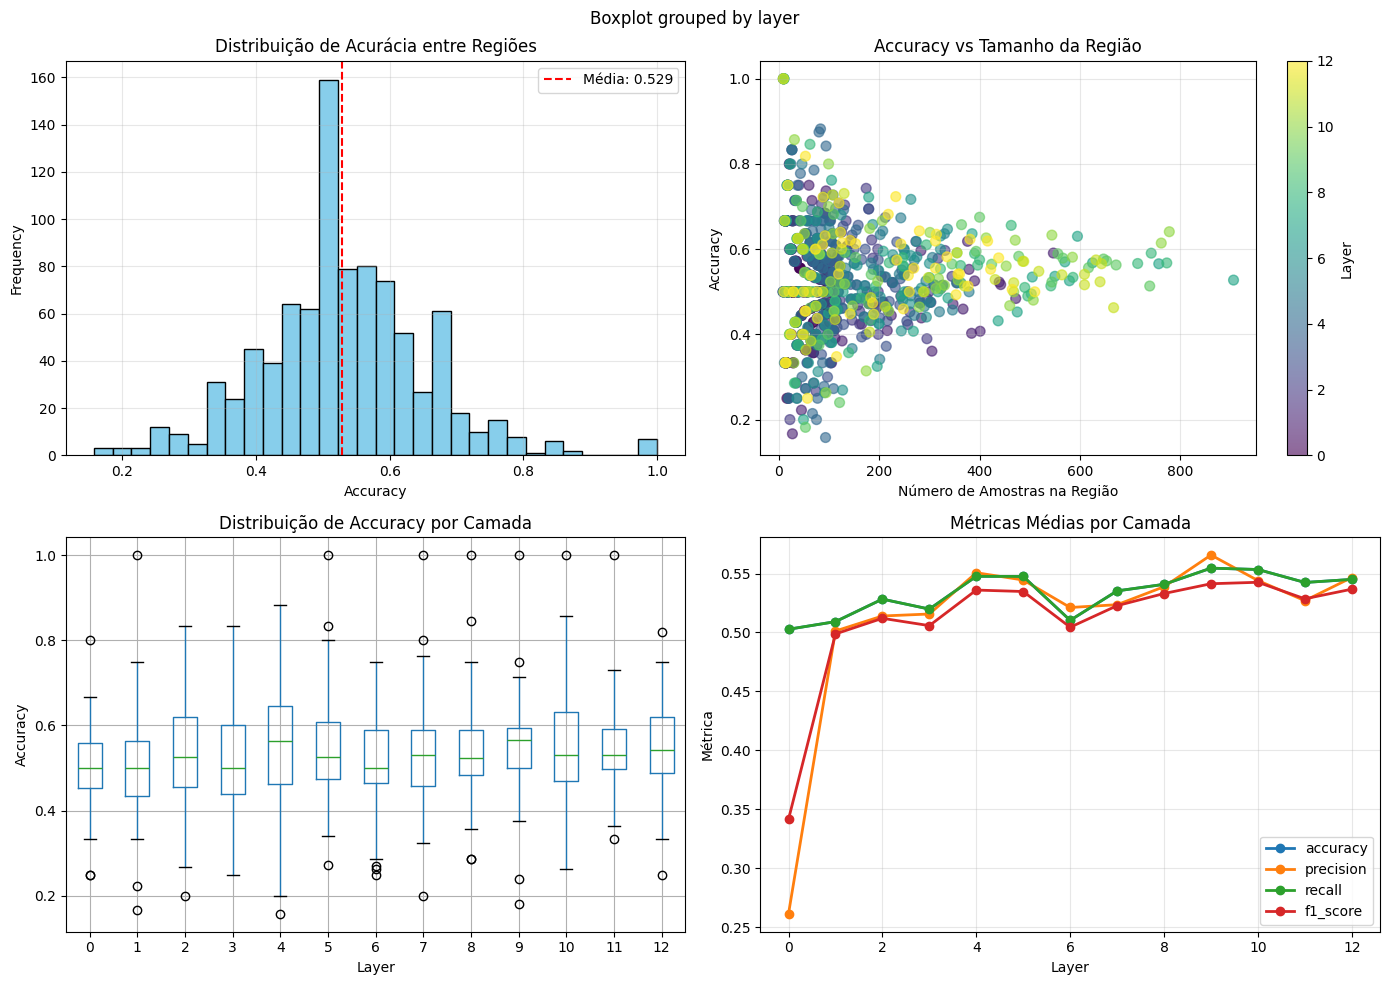


AMOSTRA DOS RESULTADOS


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
651,7,7_11_11,906,2,C:469; O:437,C:375; O:349,C:94; O:88,724,182,0.527473,0.529528,0.527473,0.526902
780,10,10_1_2,778,2,C:394; O:384,C:315; O:307,C:79; O:77,622,156,0.641026,0.641236,0.641026,0.641026
705,8,8_13_10,773,2,C:370; O:403,C:296; O:322,C:74; O:81,618,155,0.567742,0.570939,0.567742,0.567418
789,10,10_2_4,762,2,C:389; O:373,C:311; O:298,C:78; O:75,609,153,0.614379,0.614258,0.614379,0.614082
666,7,7_13_9,757,2,C:378; O:379,C:302; O:303,C:76; O:76,605,152,0.565789,0.567472,0.565789,0.563066
697,8,8_11_8,742,2,C:369; O:373,C:295; O:298,C:74; O:75,593,149,0.590604,0.591670,0.590604,0.589828
747,9,9_12_9,739,2,C:378; O:361,C:302; O:289,C:76; O:72,591,148,0.513514,0.512838,0.513514,0.512801
699,8,8_12_10,715,2,C:378; O:337,C:302; O:270,C:76; O:67,572,143,0.566434,0.565096,0.566434,0.565322
739,9,9_11_9,672,2,C:345; O:327,C:276; O:261,C:69; O:66,537,135,0.562963,0.565407,0.562963,0.561665
835,11,11_14_10,667,2,C:341; O:326,C:272; O:261,C:69; O:65,533,134,0.462687,0.460926,0.462687,0.460881


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
354,3,3_7_9,8,2,C:5; O:3,C:4; O:2,C:1; O:1,6,2,0.500000,0.250000,0.500000,0.333333
204,1,1_12_11,9,2,C:5; O:4,C:4; O:3,C:1; O:1,7,2,1.000000,1.000000,1.000000,1.000000
227,1,1_8_12,9,2,C:5; O:4,C:4; O:3,C:1; O:1,7,2,0.500000,0.250000,0.500000,0.333333
429,4,4_4_0,9,2,C:2; O:7,C:2; O:5,O:2,7,2,0.500000,1.000000,0.500000,0.666667
805,10,10_4_4,9,2,C:3; O:6,C:2; O:5,C:1; O:1,7,2,1.000000,1.000000,1.000000,1.000000
816,11,11_11_12,9,2,C:3; O:6,C:2; O:5,C:1; O:1,7,2,1.000000,1.000000,1.000000,1.000000
404,4,4_2_1,9,2,C:5; O:4,C:4; O:3,C:1; O:1,7,2,0.500000,0.250000,0.500000,0.333333
712,8,8_14_8,9,2,C:4; O:5,C:3; O:4,C:1; O:1,7,2,1.000000,1.000000,1.000000,1.000000
395,4,4_14_7,10,2,C:3; O:7,C:2; O:6,C:1; O:1,8,2,0.500000,0.250000,0.500000,0.333333
514,5,5_10_0,10,2,C:4; O:6,C:3; O:5,C:1; O:1,8,2,1.000000,1.000000,1.000000,1.000000



REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score



Dataset: sentence_length
Total de (amostra, camada, região): 129948
Unique regions: 979
Unique layers: 13

PROBING POR REGIÃO NEURAL

Regiões totais: 979
Regiões com pelo menos 8 amostras: 900
  ✓ Processadas 50 regiões...
  ✓ Processadas 100 regiões...
  ✓ Processadas 150 regiões...
  ✓ Processadas 200 regiões...
  ✓ Processadas 250 regiões...
  ✓ Processadas 300 regiões...
  ✓ Processadas 350 regiões...
  ✓ Processadas 400 regiões...
  ✓ Processadas 450 regiões...
  ✓ Processadas 500 regiões...
  ✓ Processadas 550 regiões...
  ✓ Processadas 600 regiões...

RELATÓRIO DE EXECUÇÃO - sentence_length
Total de regiões analisadas: 979
Regiões com probing bem-sucedido: 654

Regiões puladas:
  - Muito poucas amostras: 79
  - Apenas 1 classe: 9
  - Erro no split: 246
  - Erro no fit: 0

✓ Estatísticas de Acurácia:
count    654.000000
mean       0.495489
std        0.247457
min        0.000000
25%        0.304196
50%        0.483376
75%        0.666667
max        1.000000
Name: accuracy, dtype

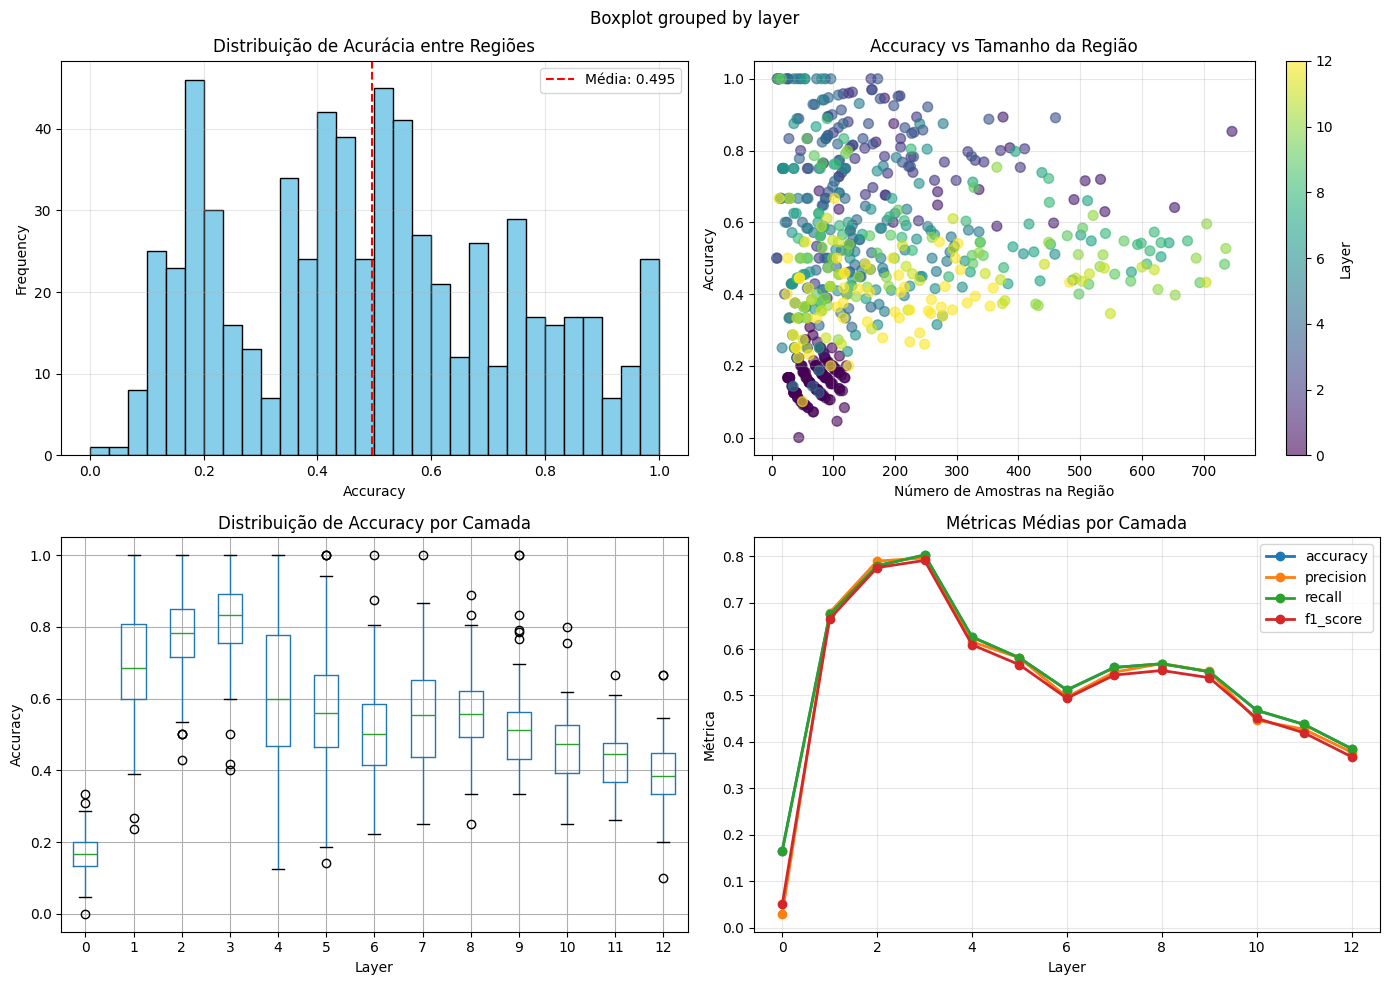


AMOSTRA DOS RESULTADOS


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
143,1,1_12_11,746,4,2:4; 3:67; 4:244; 5:431,2:3; 3:54; 4:195; 5:344,2:1; 3:13; 4:49; 5:87,596,150,0.853333,0.852122,0.853333,0.851125
535,10,10_12_11,736,6,0:168; 1:179; 2:163; 3:103; 4:73; 5:50,0:134; 1:143; 2:130; 3:82; 4:59; 5:40,0:34; 1:36; 2:33; 3:21; 4:14; 5:10,588,148,0.527027,0.526314,0.527027,0.523751
518,9,9_3_4,734,6,0:44; 1:100; 2:140; 3:156; 4:150; 5:144,0:35; 1:80; 2:112; 3:125; 4:120; 5:115,0:9; 1:20; 2:28; 3:31; 4:30; 5:29,587,147,0.482993,0.489250,0.482993,0.485173
540,10,10_13_11,705,6,0:29; 1:76; 2:148; 3:160; 4:137; 5:155,0:23; 1:61; 2:118; 3:128; 4:110; 5:124,0:6; 1:15; 2:30; 3:32; 4:27; 5:31,564,141,0.595745,0.606605,0.595745,0.594715
585,11,11_14_5,704,6,0:112; 1:113; 2:110; 3:112; 4:113; 5:144,0:90; 1:90; 2:88; 3:90; 4:90; 5:115,0:22; 1:23; 2:22; 3:22; 4:23; 5:29,563,141,0.432624,0.438918,0.432624,0.435208
520,9,9_3_6,694,6,0:13; 1:32; 2:91; 3:132; 4:191; 5:235,0:10; 1:26; 2:73; 3:105; 4:153; 5:188,0:3; 1:6; 2:18; 3:27; 4:38; 5:47,555,139,0.431655,0.414341,0.431655,0.420332
544,10,10_13_9,688,6,0:27; 1:52; 2:109; 3:147; 4:163; 5:190,0:22; 1:42; 2:87; 3:117; 4:130; 5:152,0:5; 1:10; 2:22; 3:30; 4:33; 5:38,550,138,0.500000,0.492957,0.500000,0.488734
464,8,8_12_4,674,6,0:114; 1:146; 2:169; 3:118; 4:75; 5:52,0:91; 1:117; 2:135; 3:94; 4:60; 5:42,0:23; 1:29; 2:34; 3:24; 4:15; 5:10,539,135,0.548148,0.554483,0.548148,0.549452
539,10,10_13_10,654,6,0:17; 1:59; 2:113; 3:139; 4:164; 5:162,0:14; 1:47; 2:90; 3:111; 4:131; 5:130,0:3; 1:12; 2:23; 3:28; 4:33; 5:32,523,131,0.396947,0.385890,0.396947,0.388232
142,1,1_12_10,653,5,1:17; 2:146; 3:211; 4:163; 5:116,1:13; 2:117; 3:169; 4:130; 5:93,1:4; 2:29; 3:42; 4:33; 5:23,522,131,0.641221,0.649875,0.641221,0.635415


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
253,3,3_9_6,8,2,4:3; 5:5,4:2; 5:4,4:1; 5:1,6,2,0.500000,0.250000,0.500000,0.333333
161,1,1_8_4,9,1,0:9,None,None,0,0,1.000000,1.000000,1.000000,1.000000
206,2,2_9_10,9,2,4:2; 5:7,4:2; 5:5,5:2,7,2,0.500000,1.000000,0.500000,0.666667
257,4,4_10_0,10,1,0:10,None,None,0,0,1.000000,1.000000,1.000000,1.000000
204,2,2_14_3,11,2,0:3; 1:8,0:2; 1:6,0:1; 1:2,8,3,1.000000,1.000000,1.000000,1.000000
163,2,2_0_3,11,1,0:11,None,None,0,0,1.000000,1.000000,1.000000,1.000000
509,9,9_2_1,11,2,0:5; 1:6,0:4; 1:4,0:1; 1:2,8,3,1.000000,1.000000,1.000000,1.000000
159,1,1_2_8,12,3,2:5; 3:2; 4:5,2:4; 3:1; 4:4,2:1; 3:1; 4:1,9,3,1.000000,1.000000,1.000000,1.000000
647,12,12_7_1,12,2,4:4; 5:8,4:3; 5:6,4:1; 5:2,9,3,0.666667,0.833333,0.666667,0.666667
363,5,5_14_1,13,1,0:13,None,None,0,0,1.000000,1.000000,1.000000,1.000000



REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)


,layer,region_id,n_samples,n_classes,class_distribution,train_distribution,test_distribution,n_train,n_test,accuracy,precision,recall,f1_score
313,4,4_9_0,96,1,0:96,None,None,0,0,1.0,1.0,1.0,1.0
276,4,4_12_2,73,1,0:73,None,None,0,0,1.0,1.0,1.0,1.0
189,2,2_13_0,47,1,0:47,None,None,0,0,1.0,1.0,1.0,1.0
220,3,3_11_0,26,1,0:26,None,None,0,0,1.0,1.0,1.0,1.0
501,9,9_13_9,16,1,0:16,None,None,0,0,1.0,1.0,1.0,1.0
363,5,5_14_1,13,1,0:13,None,None,0,0,1.0,1.0,1.0,1.0
163,2,2_0_3,11,1,0:11,None,None,0,0,1.0,1.0,1.0,1.0
257,4,4_10_0,10,1,0:10,None,None,0,0,1.0,1.0,1.0,1.0
161,1,1_8_4,9,1,0:9,None,None,0,0,1.0,1.0,1.0,1.0


In [22]:
import h5py
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


min_samples_per_region = 8 

for dataset_name in DATASETS_NAMES:


    # =============================================================================
    # 1. CARREGAR DADOS SALVOS
    # =============================================================================

    df_assignments = pd.read_csv(
        f'{INTERIM_DATASET_PATH}/neural_regions_{dataset_name}/region_assignments.csv'
    )
    
    print("\n" + "="*60)
    print(f"Dataset: {dataset_name}")
    print("="*60)
    
    print(f"Total de (amostra, camada, região): {len(df_assignments)}")
    print(f"Unique regions: {df_assignments['region_id'].nunique()}")
    print(f"Unique layers: {df_assignments['layer'].nunique()}")

    activation_file = f'{INTERIM_DATASET_PATH}/neural_regions_{dataset_name}/region_activations.h5'

    # =============================================================================
    # 2. FUNÇÃO AUXILIAR PARA CARREGAR ATIVAÇÕES
    # =============================================================================

    def load_region_activations_hdf5(h5_file, layer_idx, region_id):
        """Carrega ativações 768D para uma região específica."""
        with h5py.File(h5_file, 'r') as f:
            group_name = f"layer_{layer_idx}_{region_id}"
            if group_name not in f:
                return None, None, None
            
            group = f[group_name]
            activations = group['activations'][:]
            sample_ids = group['sample_ids'][:]
            class_labels = group['class_labels'][:]
        
        return activations, sample_ids, class_labels

    # =============================================================================
    # 3. PROBING POR REGIÃO (COM TRATAMENTO DE ERROS)
    # =============================================================================

    results_list = []
    skipped_regions = {
        'too_few_samples': 0,
        'only_one_class': 0,
        'split_error': 0,
        'fit_error': 0
    }

    

    print("\n" + "="*60)
    print("PROBING POR REGIÃO NEURAL")
    print("="*60)

    region_counts = df_assignments.groupby(['layer', 'region_id']).size()
    total_regions = len(region_counts)

    print(f"\nRegiões totais: {total_regions}")
    print(f"Regiões com pelo menos {min_samples_per_region} amostras: {(region_counts >= min_samples_per_region).sum()}")

    processed_count = 0

    for (layer_idx, region_id), count in region_counts.items():
        
        # Filtro 1: mínimo de amostras
        if count < min_samples_per_region:
            skipped_regions['too_few_samples'] += 1
            continue
        
        # Carregar ativações
        X_region, sample_ids, class_labels_region = load_region_activations_hdf5(
            activation_file, layer_idx, region_id
        )
        
        if X_region is None:
            continue
        
        # Converter labels de bytes para string (já estão em formato legível)
        y_region = np.array([
            label.decode('utf-8') if isinstance(label, bytes) else str(label)
            for label in class_labels_region
        ])
        
        # Filtro 2: verificar se tem pelo menos 2 classes
        unique_classes, class_counts = np.unique(y_region, return_counts=True)
        if len(unique_classes) < 2:
            skipped_regions['only_one_class'] += 1
            
            
            # Add region with unique class to results with NaN metrics
            # Faz sentido adicionar regiões com valor unico como resultado final 1?
            results_list.append({
                'layer': layer_idx,
                'region_id': region_id,
                'n_samples': len(X_region),
                'n_classes': len(unique_classes),
                'class_distribution':  '; '.join([f"{cls}:{cnt}" for cls, cnt in zip(unique_classes, class_counts)]),
                'train_distribution': None,
                'test_distribution': None,
                'n_train': 0,
                'n_test': 0,
                # Assumir acurácia perfeita para região com classe única
                'accuracy': 1,
                'precision': 1,
                'recall': 1,
                'f1_score': 1
            })
            continue
        
        # Filtro 3: evitar split que resulte em classe única no train
        # Estratificar garante que cada classe fica em ambos os conjuntos
        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X_region, y_region, 
                test_size=0.20, 
                random_state=42, 
                stratify=y_region
            )
        except ValueError as e:
            skipped_regions['split_error'] += 1
            continue
        
        # Verificação extra: confirmar que train set tem 2+ classes
        if len(np.unique(y_train)) < 2:
            skipped_regions['only_one_class'] += 1
            continue
        
        # Treinar probe
        try:
            probe = LogisticRegression(
                max_iter=1000, 
                # The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))
                class_weight='balanced',
                random_state=42,
                solver='lbfgs'  # Pode ajudar com convergência
            )
            probe.fit(X_train, y_train)
        except Exception as e:
            skipped_regions['fit_error'] += 1
            continue
        
        # Avaliar
        predictions = probe.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
        recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
        f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
        
        # Criar distribuição de classes como string formatada
        class_distribution = '; '.join([f"{cls}:{cnt}" for cls, cnt in zip(unique_classes, class_counts)])
        
        # Contar classes no train
        train_unique, train_counts = np.unique(y_train, return_counts=True)
        train_distribution = '; '.join([f"{cls}:{cnt}" for cls, cnt in zip(train_unique, train_counts)])
        
        # Contar classes no test
        test_unique, test_counts = np.unique(y_test, return_counts=True)
        test_distribution = '; '.join([f"{cls}:{cnt}" for cls, cnt in zip(test_unique, test_counts)])
        
        # Armazenar resultado
        results_list.append({
            'layer': layer_idx,
            'region_id': region_id,
            'n_samples': len(X_region),
            'n_classes': len(unique_classes),
            'class_distribution': class_distribution,
            'train_distribution': train_distribution,
            'test_distribution': test_distribution,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        })
        
        processed_count += 1
        if processed_count % 50 == 0:
            print(f"  ✓ Processadas {processed_count} regiões...")

    # Criar DataFrame
    df_probing_region = pd.DataFrame(results_list)
    
    

    # =============================================================================
    # 4. RELATÓRIO
    # =============================================================================

    print(f"\n" + "="*60)
    print(f"RELATÓRIO DE EXECUÇÃO - {dataset_name}")
    print("="*60)
    print(f"Total de regiões analisadas: {total_regions}")
    print(f"Regiões com probing bem-sucedido: {len(df_probing_region)}")
    print(f"\nRegiões puladas:")
    print(f"  - Muito poucas amostras: {skipped_regions['too_few_samples']}")
    print(f"  - Apenas 1 classe: {skipped_regions['only_one_class']}")
    print(f"  - Erro no split: {skipped_regions['split_error']}")
    print(f"  - Erro no fit: {skipped_regions['fit_error']}")

    if len(df_probing_region) > 0:
        print(f"\n✓ Estatísticas de Acurácia:")
        print(df_probing_region['accuracy'].describe())
        
        # Salvar resultados
        output_path = f'{PROCESSED_DATASET_PATH}/probing_{dataset_name}_by_region.csv'
        df_probing_region.to_csv(output_path, index=False)
        print(f"\n✓ Resultados salvos em: {output_path}")
    else:
        print("\n❌ Nenhuma região foi processada com sucesso!")

    # =============================================================================
    # 5. VISUALIZAR RESULTADOS
    # =============================================================================

    if len(df_probing_region) > 0:
        
        # Gráfico 1: Distribuição de acurácias
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Análise de Probing por Região - {dataset_name}', 
             fontsize=16, fontweight='bold', y=0.995)
        
        # Histograma de acurácia
        axes[0, 0].hist(df_probing_region['accuracy'], bins=30, color='skyblue', edgecolor='black')
        axes[0, 0].set_xlabel('Accuracy')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribuição de Acurácia entre Regiões')
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].axvline(df_probing_region['accuracy'].mean(), color='red', 
                        linestyle='--', label=f"Média: {df_probing_region['accuracy'].mean():.3f}")
        axes[0, 0].legend()
        
        # Acurácia vs Número de Amostras
        scatter = axes[0, 1].scatter(
            df_probing_region['n_samples'], 
            df_probing_region['accuracy'],
            alpha=0.6, 
            c=df_probing_region['layer'], 
            cmap='viridis',
            s=50
        )
        axes[0, 1].set_xlabel('Número de Amostras na Região')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Accuracy vs Tamanho da Região')
        plt.colorbar(scatter, ax=axes[0, 1], label='Layer')
        axes[0, 1].grid(alpha=0.3)
        
        # Acurácia por camada (box plot)
        df_probing_region.boxplot(column='accuracy', by='layer', ax=axes[1, 0])
        axes[1, 0].set_xlabel('Layer')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 0].set_title('Distribuição de Accuracy por Camada')
        plt.sca(axes[1, 0])
        plt.xticks(rotation=0)
        
        # Métricas por camada (agregado)
        df_by_layer = df_probing_region.groupby('layer')[['accuracy', 'precision', 'recall', 'f1_score']].mean()
        df_by_layer.plot(ax=axes[1, 1], marker='o', linewidth=2)
        axes[1, 1].set_xlabel('Layer')
        axes[1, 1].set_ylabel('Métrica')
        axes[1, 1].set_title('Métricas Médias por Camada')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*60)
        print("AMOSTRA DOS RESULTADOS")
        print("="*60)
        display(df_probing_region.sort_values('n_samples', ascending=False).head(20))
        display(df_probing_region.sort_values('n_samples', ascending=True).head(20))
        
        print("\n" + "="*60)
        print("REGIÕES COM SOMENTE UMA CLASSE (ACURÁCIA PERFEITA ASSUMIDA)")
        print("="*60)        
        display(df_probing_region[df_probing_region['n_classes'] == 1].sort_values('n_samples', ascending=False))

# Extract Graph Metrics

In [ ]:
from utils.nodes1 import get_node_metric_function

def get_labels_dict():
  d = dict()
  for dataset_name in DATASETS_NAMES:
    df = pd.read_csv(
        f"{RAW_DATASET_PATH}{dataset_name}.txt",
        sep="\t",
        names=["split", "label", "text"],
        quoting=csv.QUOTE_NONE
    )    
    d[dataset_name] = sorted(df['label'].unique().tolist())
    d[dataset_name].append('total')
  return d

def convert_node_metrics_to_dataframe(metrics_dict):
    """
    Converte dicionários de métricas por nó para um DataFrame.
    
    Args:
        metrics_dict: dicionário {metric_name: {node: value}}
    
    Returns:
        DataFrame com colunas: node, layer, x, y, e uma coluna para cada métrica
    """
    if not metrics_dict:
        return pd.DataFrame()
    
    # Pega o primeiro dicionário de métrica para obter os nós
    first_metric = next(iter(metrics_dict.values()))
    nodes = list(first_metric.keys())
    
    # Extrai layer, x, y de cada nó
    data = []
    for node in nodes:
        row = {"node": node}
        row["layer"] = int(node.split("_")[0])
        row["x"] = int(node.split("_")[1])
        row["y"] = int(node.split("_")[2])
        
        # Adiciona cada métrica
        for metric_name, metric_values in metrics_dict.items():
            row[metric_name] = metric_values.get(node, None)
        
        data.append(row)
    
    return pd.DataFrame(data)


# Calcular as métricas locais para cada grafo filtrado e salvar em CSV
print("=" * 60)
print("CALCULANDO MÉTRICAS LOCAIS POR NÓ")
print("=" * 60)

labels_dict = get_labels_dict()

for dataset_name in DATASETS_NAMES:
    # for label in labels_dict[dataset_name]:
    for label in ["total"]:
        print(f"\nProcessando: {dataset_name} - {label}")
        
        # Carregar grafo
        graph_path = f"{COMPLETE_GRAPH_PATH}g_{label}_{dataset_name}.gexf"
        try:
            current_graph = nx.read_gexf(graph_path)
        except FileNotFoundError:
            print(f"  ⚠ Grafo não encontrado: {graph_path}")
            continue
        
        if len(current_graph) == 0:
            print(f"  ⚠ Grafo vazio para {dataset_name} - {label}")
            continue
        
        # Calcular todas as métricas locais
        metrics_per_node = {}
        for metric_name, metric_func in get_node_metric_function().items():
            try:
                metrics_per_node[metric_name] = metric_func(current_graph)
                print(f"  ✓ {metric_name}")
            except Exception as e:
                print(f"  ✗ Erro em {metric_name}: {str(e)}")
        
        # Converter para DataFrame
        df_metrics = convert_node_metrics_to_dataframe(metrics_per_node)
        
        # Salvar
        output_file = f'{PROCESSED_DATASET_PATH}/node_metrics_{dataset_name}_{label}.csv'
        df_metrics.to_csv(output_file, index=False)
        print(f"  ✓ Salvo em: {output_file}")
        print(f"    - {len(df_metrics)} nós com {len(df_metrics.columns)} colunas")
        

CALCULANDO MÉTRICAS LOCAIS POR NÓ

Processando: subj_number - total
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✓ eigenvector_centrality
  ✗ Erro em eccentricity: not implemented for directed type
  ✓ kcore
  ✓ Salvo em: data/processed//node_metrics_subj_number_total.csv
    - 928 nós com 10 colunas

Processando: tree_depth - total
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✗ Erro em eigenvector_centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
  ✗ Erro em eccentricity: not implemented for directed type
  ✓ kcore
  ✓ Salvo em: data/processed//node_metrics_tree_depth_total.csv
    - 857 nós com 9 colunas

Processando: word_content - total
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✗ Erro em eigenvector_centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
  ✗ Err

# Correlation

ANÁLISE DE CORRELAÇÃO E P-VALUES POR REGIÃO PARA subj_number

✓ Métricas de rede complexa carregadas: 928 regiões
  Colunas: ['region_id', 'layer', 'x', 'y', 'degree']... (total: 10)

✓ Dados de probing carregados: 855 regiões
  Colunas: ['layer', 'region_id', 'n_samples', 'n_classes', 'class_distribution', 'train_distribution', 'test_distribution', 'n_train', 'n_test', 'accuracy', 'precision', 'recall', 'f1_score']

✓ Merge realizado: 855 regiões com dados completos

✓ Colunas numéricas para correlação: 10
  Exemplos: ['degree', 'node_betweenness', 'node_strength', 'average_neighbor_degree', 'eigenvector_centrality']...

CALCULANDO MATRIZES DE CORRELAÇÃO E P-VALUES

Calculando p-values para 10 x 10 pares de variáveis...
  Processadas 5/10 colunas...
  Processadas 10/10 colunas...
✓ Matrizes calculadas!

✓ Métricas de Rede encontradas: ['degree', 'node_betweenness', 'node_strength', 'average_neighbor_degree', 'eigenvector_centrality', 'kcore']
✓ Métricas de Probing encontradas: ['accur

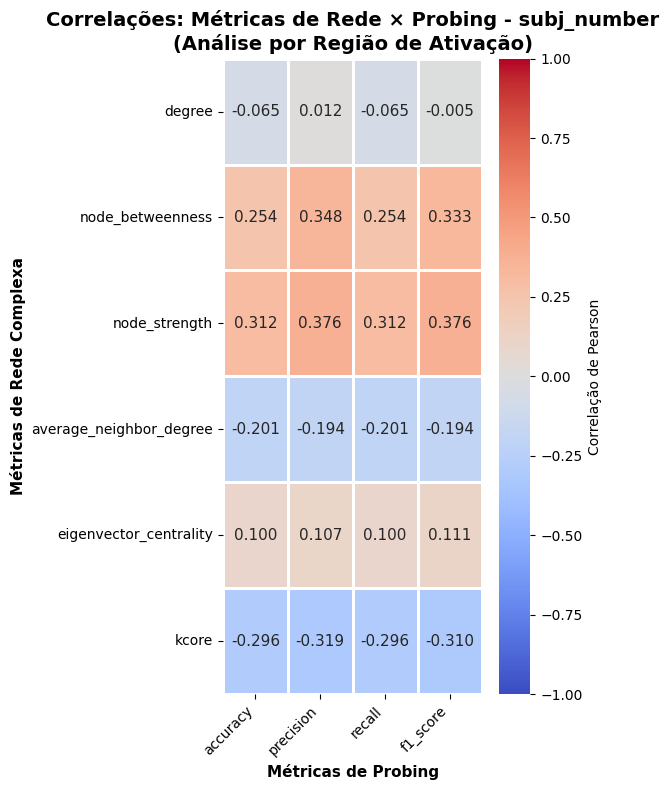

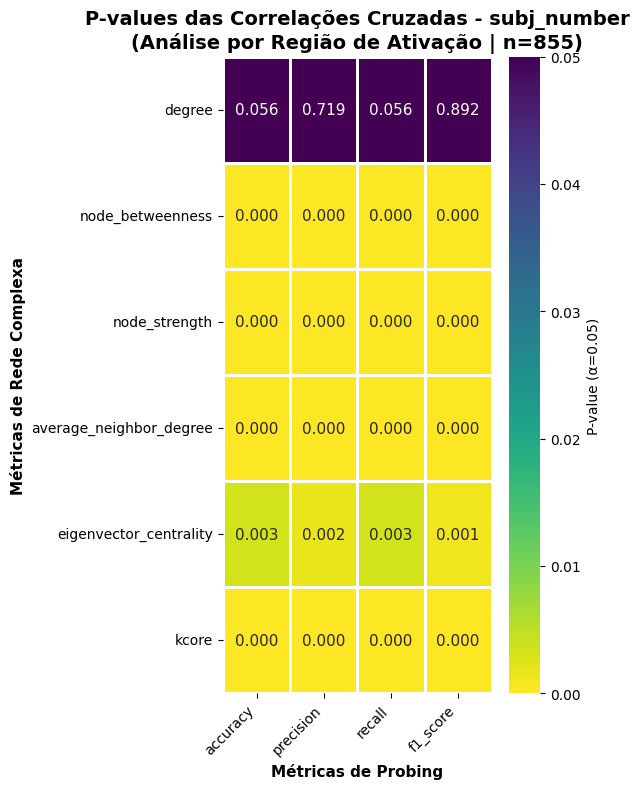


RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - subj_number

Número de regiões analisadas: 855
Métricas de Rede: 6
Métricas de Probing: 4
Total de correlações cruzadas: 24

Correlações SIGNIFICATIVAS - subj_number - (p < 0.05): 20

Top 10 correlações mais significativas:
  network_metric probing_metric  correlation      p_value
   node_strength       f1_score     0.375891 4.394460e-30
   node_strength      precision     0.375821 4.512204e-30
node_betweenness      precision     0.348025 9.481143e-26
node_betweenness       f1_score     0.333484 1.179826e-23
           kcore      precision    -0.319426 9.842943e-22
   node_strength       accuracy     0.312183 8.794659e-21
   node_strength         recall     0.312183 8.794659e-21
           kcore       f1_score    -0.310497 1.451489e-20
           kcore         recall    -0.295787 1.003761e-18
           kcore       accuracy    -0.295787 1.003761e-18

Correlações ALTAMENTE significativas (p < 0.01): 20
Correlações MARGINALMEN

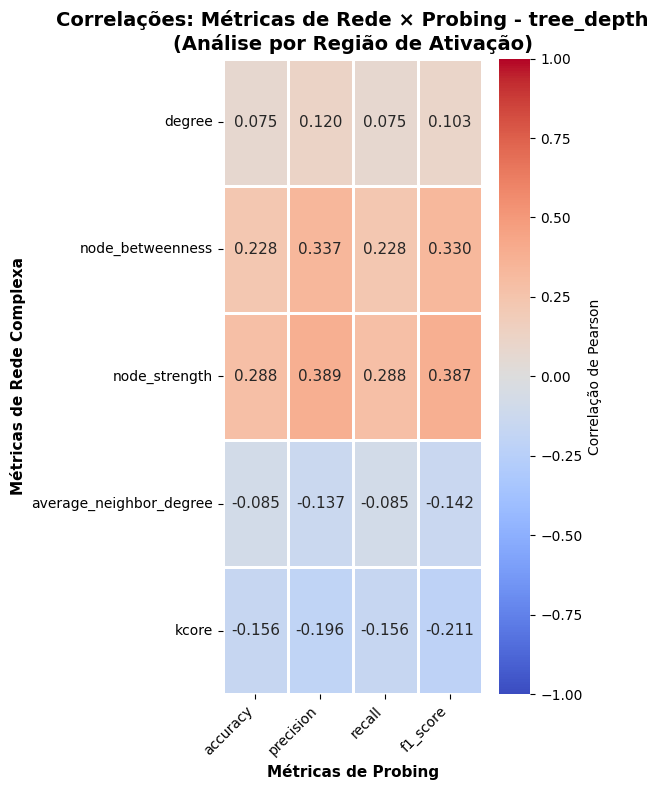

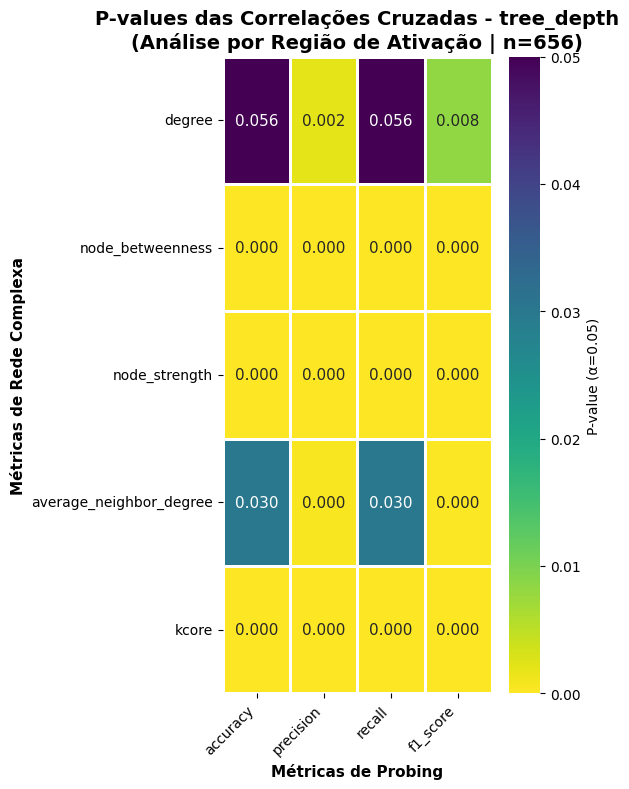


RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - tree_depth

Número de regiões analisadas: 656
Métricas de Rede: 5
Métricas de Probing: 4
Total de correlações cruzadas: 20

Correlações SIGNIFICATIVAS - tree_depth - (p < 0.05): 18

Top 10 correlações mais significativas:
  network_metric probing_metric  correlation      p_value
   node_strength      precision     0.389208 3.734126e-25
   node_strength       f1_score     0.386871 7.550738e-25
node_betweenness      precision     0.336869 7.170013e-19
node_betweenness       f1_score     0.330152 3.802008e-18
   node_strength         recall     0.287956 5.432907e-14
   node_strength       accuracy     0.287956 5.432907e-14
node_betweenness       accuracy     0.228491 3.228457e-09
node_betweenness         recall     0.228491 3.228457e-09
           kcore       f1_score    -0.211099 4.813259e-08
           kcore      precision    -0.196239 4.064351e-07

Correlações ALTAMENTE significativas (p < 0.01): 16
Correlações MARGINALMENTE

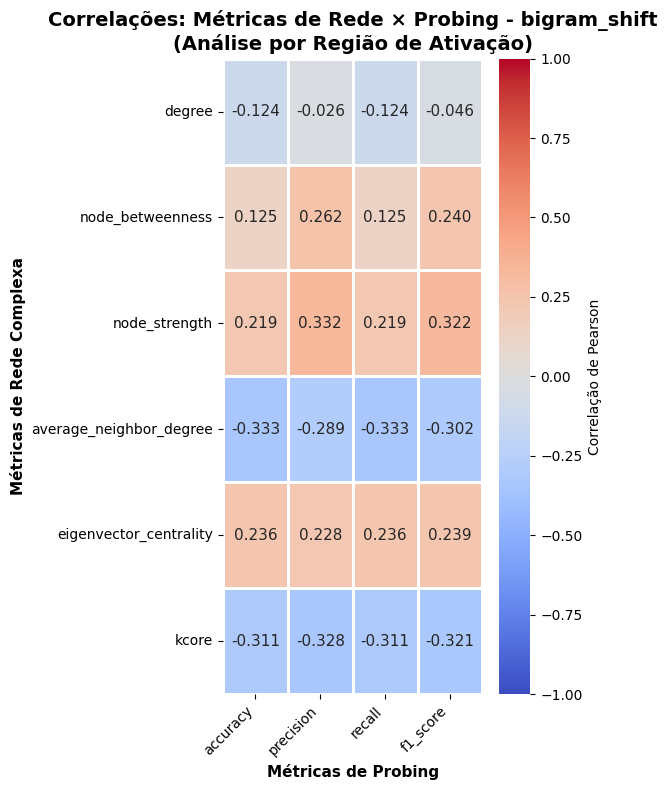

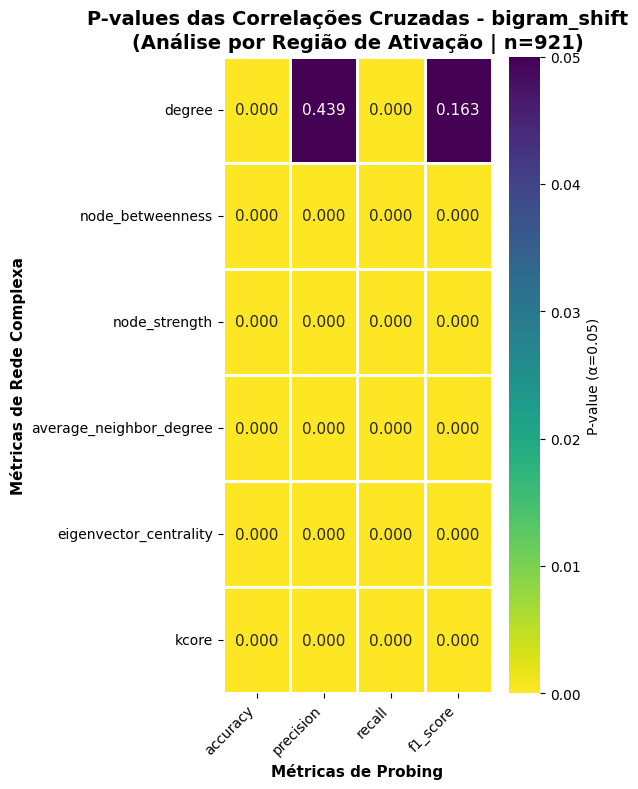


RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - bigram_shift

Número de regiões analisadas: 921
Métricas de Rede: 6
Métricas de Probing: 4
Total de correlações cruzadas: 24

Correlações SIGNIFICATIVAS - bigram_shift - (p < 0.05): 22

Top 10 correlações mais significativas:
         network_metric probing_metric  correlation      p_value
average_neighbor_degree         recall    -0.333292 2.484457e-25
average_neighbor_degree       accuracy    -0.333292 2.484457e-25
          node_strength      precision     0.331924 3.992128e-25
                  kcore      precision    -0.328296 1.387783e-24
          node_strength       f1_score     0.321946 1.180252e-23
                  kcore       f1_score    -0.320744 1.760189e-23
                  kcore       accuracy    -0.311357 3.747529e-22
                  kcore         recall    -0.311357 3.747529e-22
average_neighbor_degree       f1_score    -0.301846 7.438575e-21
average_neighbor_degree      precision    -0.288813 3.743896e-

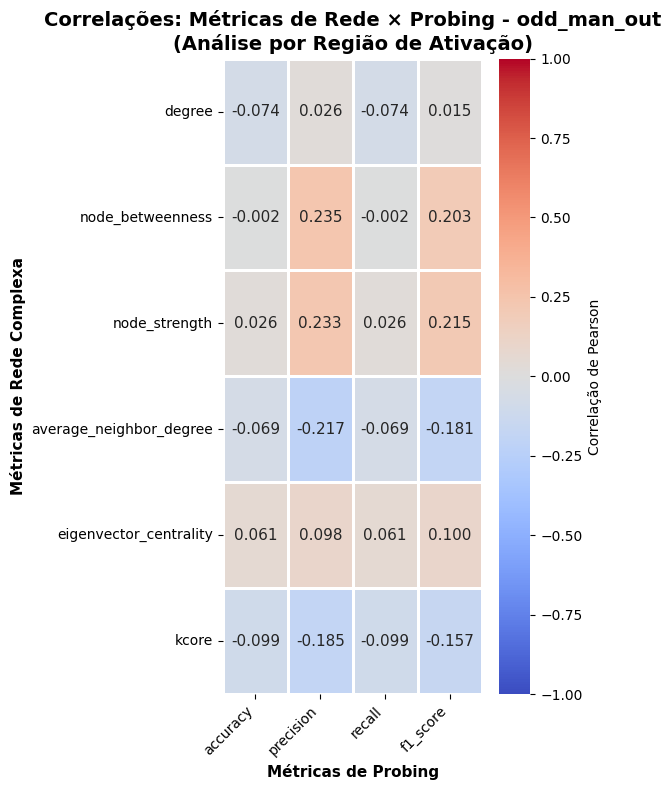

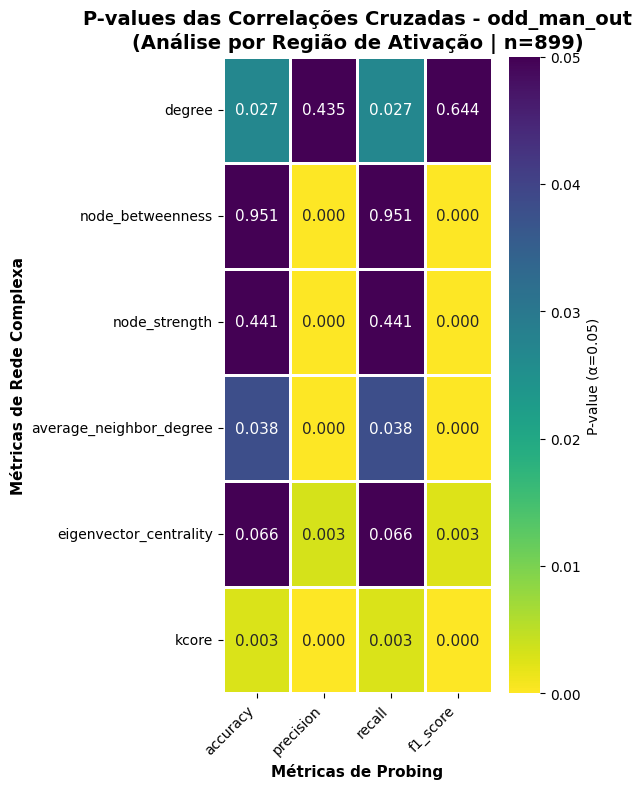


RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - odd_man_out

Número de regiões analisadas: 899
Métricas de Rede: 6
Métricas de Probing: 4
Total de correlações cruzadas: 24

Correlações SIGNIFICATIVAS - odd_man_out - (p < 0.05): 16

Top 10 correlações mais significativas:
         network_metric probing_metric  correlation      p_value
       node_betweenness      precision     0.234995 9.587153e-13
          node_strength      precision     0.232542 1.668736e-12
average_neighbor_degree      precision    -0.216602 5.256590e-11
          node_strength       f1_score     0.215248 6.962151e-11
       node_betweenness       f1_score     0.202814 8.438221e-10
                  kcore      precision    -0.184890 2.348888e-08
average_neighbor_degree       f1_score    -0.181285 4.415644e-08
                  kcore       f1_score    -0.156801 2.310900e-06
 eigenvector_centrality       f1_score     0.100231 2.624025e-03
                  kcore       accuracy    -0.099356 2.861143e-03

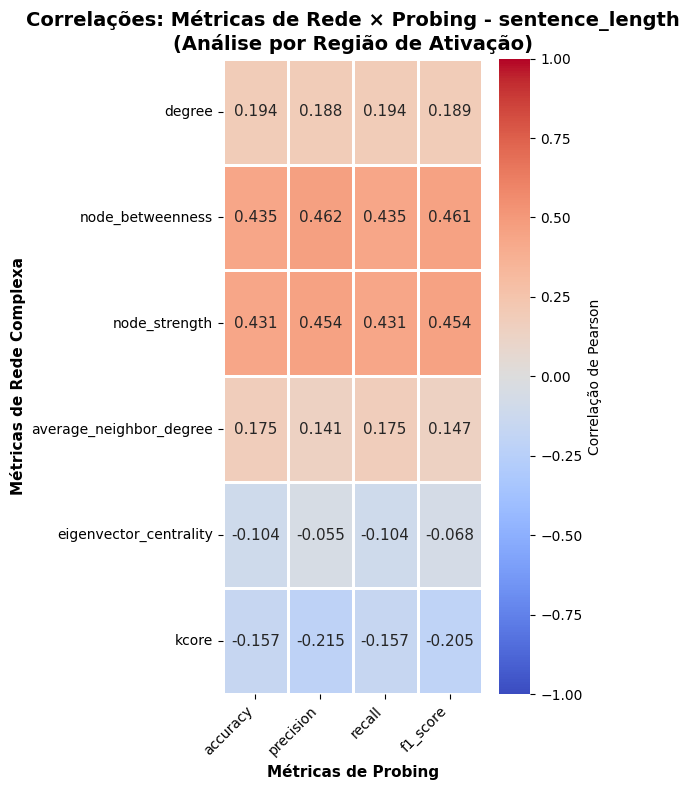

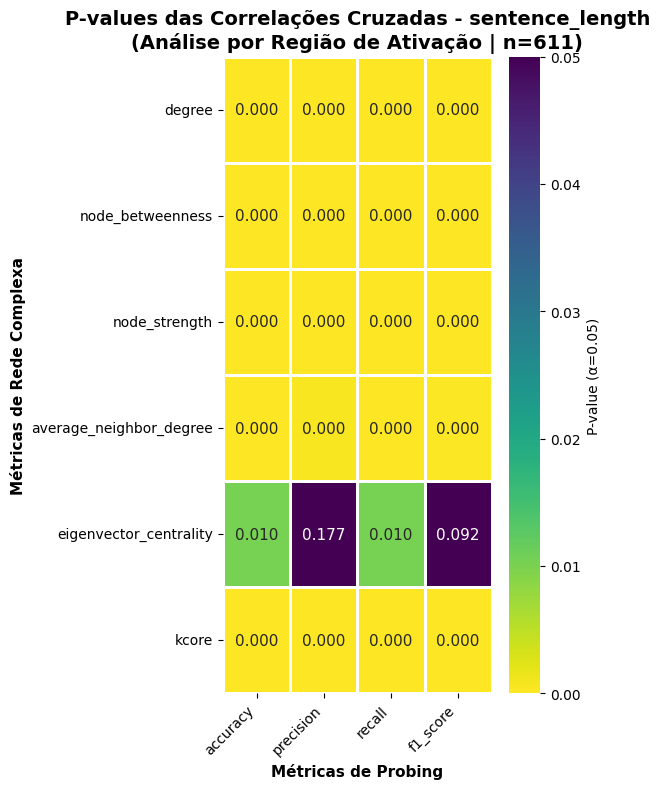


RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - sentence_length

Número de regiões analisadas: 611
Métricas de Rede: 6
Métricas de Probing: 4
Total de correlações cruzadas: 24

Correlações SIGNIFICATIVAS - sentence_length - (p < 0.05): 22

Top 10 correlações mais significativas:
  network_metric probing_metric  correlation      p_value
node_betweenness      precision     0.462292 1.112531e-33
node_betweenness       f1_score     0.460811 1.894134e-33
   node_strength       f1_score     0.454482 1.787924e-32
   node_strength      precision     0.454186 1.983129e-32
node_betweenness         recall     0.435432 1.165254e-29
node_betweenness       accuracy     0.435432 1.165254e-29
   node_strength         recall     0.431069 4.854594e-29
   node_strength       accuracy     0.431069 4.854594e-29
           kcore      precision    -0.215183 7.824559e-08
           kcore       f1_score    -0.205335 3.058502e-07

Correlações ALTAMENTE significativas (p < 0.01): 20
Correlações MAR

In [28]:
find_error = []
for dataset_name in DATASETS_NAMES:

    # ==========================================
    # CORRELAÇÃO E P-VALUES POR REGIÃO
    # ==========================================
    # Análise de correlação entre métricas de rede complexa (nó/região)
    # e resultados de probing em nível de REGIÃO
    # (Mais dados que análise por camada, p-values mais robustos)

    print("=" * 70)
    print("ANÁLISE DE CORRELAÇÃO E P-VALUES POR REGIÃO PARA {}".format(dataset_name))
    print("=" * 70)

    # Carregar métricas de rede complexa por nó/região
    # (usando o dataset 'total' que agrega todas as classes)
    df_node_metrics = pd.read_csv(
        f'{PROCESSED_DATASET_PATH}/node_metrics_{dataset_name}_total.csv'
    )

    # Renomear 'node' para 'region_id' para facilitar o merge
    df_node_metrics = df_node_metrics.rename(columns={'node': 'region_id'})

    # Carregar dados de probing por região
    try:
        df_probing_region = pd.read_csv(
        f'{PROCESSED_DATASET_PATH}/probing_{dataset_name}_by_region.csv'
    )
    except FileNotFoundError:
        print(f" ⚠ Arquivo não encontrado: {PROCESSED_DATASET_PATH}/probing_{dataset_name}_by_region.csv")
        find_error.append(dataset_name)
        continue

    print(f"\n✓ Métricas de rede complexa carregadas: {len(df_node_metrics)} regiões")
    print(f"  Colunas: {df_node_metrics.columns.tolist()[:5]}... (total: {len(df_node_metrics.columns)})")

    print(f"\n✓ Dados de probing carregados: {len(df_probing_region)} regiões")
    print(f"  Colunas: {df_probing_region.columns.tolist()}")

    # ==========================================
    # MERGE DOS DATAFRAMES
    # ==========================================
    # Fazer merge baseado em 'layer' e 'region_id'
    df_merged = pd.merge(
        df_node_metrics,
        df_probing_region[['layer', 'region_id', 'accuracy', 'precision', 'recall', 'f1_score']],
        on=['layer', 'region_id'],
        how='inner'
    )

    print(f"\n✓ Merge realizado: {len(df_merged)} regiões com dados completos")

    # Remover colunas não-numéricas que não são métricas
    cols_to_drop = ['region_id', 'layer', 'x', 'y']
    df_numeric = df_merged.drop(cols_to_drop, axis=1)
    df_numeric = df_numeric.select_dtypes(include=[np.number])

    cols = df_numeric.columns
    print(f"\n✓ Colunas numéricas para correlação: {len(cols)}")
    print(f"  Exemplos: {cols.tolist()[:5]}...")

    # ==========================================
    # CÁLCULO DAS MATRIZES DE CORRELAÇÃO E P-VALUES
    # ==========================================
    print("\n" + "=" * 70)
    print("CALCULANDO MATRIZES DE CORRELAÇÃO E P-VALUES")
    print("=" * 70)

    # 1. Matriz de Correlação
    correlation_matrix = df_numeric.corr()

    # 2. Matriz de P-values
    p_values_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)

    print(f"\nCalculando p-values para {len(cols)} x {len(cols)} pares de variáveis...")
    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            if col1 == col2:
                p_values_matrix.loc[col1, col2] = 0.0
            else:
                valid_data = df_numeric[[col1, col2]].dropna()
                if len(valid_data) > 1:
                    corr, p_val = pearsonr(valid_data[col1], valid_data[col2])
                    p_values_matrix.loc[col1, col2] = p_val
                else:
                    p_values_matrix.loc[col1, col2] = np.nan
        
        if (i + 1) % 5 == 0:
            print(f"  Processadas {i + 1}/{len(cols)} colunas...")

    print(f"✓ Matrizes calculadas!")

    # ==========================================
    # SEPARAR VARIÁVEIS POR CATEGORIA
    # ==========================================
    network_metrics = ['degree', 'node_betweenness', 'node_strength', 
                       'average_neighbor_degree', 'eigenvector_centrality', 'kcore']
    probing_metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    
    # Filtar apenas as colunas que existem no dataframe
    network_metrics = [m for m in network_metrics if m in cols]
    probing_metrics = [m for m in probing_metrics if m in cols]
    
    print(f"\n✓ Métricas de Rede encontradas: {network_metrics}")
    print(f"✓ Métricas de Probing encontradas: {probing_metrics}")

    # ==========================================
    # HEATMAP 1: CORRELAÇÃO CRUZADA (Rede × Probing)
    # ==========================================
    cross_corr_matrix = correlation_matrix.loc[network_metrics, probing_metrics]
    
    plt.figure(figsize=(6, 8))
    sns.heatmap(
        cross_corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        linewidths=1,
        cbar_kws={'label': 'Correlação de Pearson'},
        annot_kws={'size': 11}
    )
    plt.title(f'Correlações: Métricas de Rede × Probing - {dataset_name}\n(Análise por Região de Ativação)', 
            fontweight='bold', fontsize=14)
    plt.xlabel('Métricas de Probing', fontweight='bold', fontsize=11)
    plt.ylabel('Métricas de Rede Complexa', fontweight='bold', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # HEATMAP 2: P-VALUES CRUZADOS
    # ==========================================
    cross_pvalues_matrix = p_values_matrix.loc[network_metrics, probing_metrics]
    
    plt.figure(figsize=(6, 8))
    sns.heatmap(
        cross_pvalues_matrix,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        vmin=0,
        vmax=0.05,  # Focar em nível de significância de 5%
        square=False,
        linewidths=1,
        cbar_kws={'label': 'P-value (α=0.05)'},
        annot_kws={'size': 11}
    )
    plt.title(f'P-values das Correlações Cruzadas - {dataset_name}\n(Análise por Região de Ativação | n={len(df_merged)})',
            fontweight='bold', fontsize=14)
    plt.xlabel('Métricas de Probing', fontweight='bold', fontsize=11)
    plt.ylabel('Métricas de Rede Complexa', fontweight='bold', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # RESUMO ESTATÍSTICO - APENAS CORRELAÇÕES CRUZADAS
    # ==========================================
    print("\n" + "=" * 70)
    print("RESUMO ESTATÍSTICO - CORRELAÇÕES CRUZADAS (Rede × Probing) - {}".format(dataset_name))
    print("=" * 70)

    print(f"\nNúmero de regiões analisadas: {len(df_merged)}")
    print(f"Métricas de Rede: {len(network_metrics)}")
    print(f"Métricas de Probing: {len(probing_metrics)}")
    print(f"Total de correlações cruzadas: {len(network_metrics) * len(probing_metrics)}")

    # Correlações significativas (p < 0.05) - APENAS CRUZADAS
    sig_pairs = []
    for net_metric in network_metrics:
        for prob_metric in probing_metrics:
            p_val = p_values_matrix.loc[net_metric, prob_metric]
            if not np.isnan(p_val) and p_val < 0.05:
                corr_val = correlation_matrix.loc[net_metric, prob_metric]
                sig_pairs.append({
                    'network_metric': net_metric,
                    'probing_metric': prob_metric,
                    'correlation': corr_val,
                    'p_value': p_val
                })

    sig_pairs_df = pd.DataFrame(sig_pairs).sort_values('p_value')

    print(f"\nCorrelações SIGNIFICATIVAS - {dataset_name} - (p < 0.05): {len(sig_pairs_df)}")
    if len(sig_pairs_df) > 0:
        print("\nTop 10 correlações mais significativas:")
        print(sig_pairs_df.head(10).to_string(index=False))
    else:
        print("Nenhuma correlação significativa encontrada com p < 0.05")

    print(f"\nCorrelações ALTAMENTE significativas (p < 0.01): {len(sig_pairs_df[sig_pairs_df['p_value'] < 0.01])}")
    print(f"Correlações MARGINALMENTE significativas (0.05 ≤ p < 0.10): {len(sig_pairs_df[(sig_pairs_df['p_value'] >= 0.05) & (sig_pairs_df['p_value'] < 0.10)])}")

    print("\n" + "=" * 70)
    print("ANÁLISE CONCLUÍDA")
    print("=" * 70)

print("\n" + "=" * 70)
print("Find erros nos datasets:")
print("=" * 70)
for dataset in find_error:
    print(f"  ⚠ {dataset}")    
print("\n" + "=" * 70)
